In [2]:
import os
import h5py

import sys
from pathlib import Path

project_root = Path().resolve().parent
src_path = project_root / "src"

sys.path.append(str(src_path))

from training.fno_training import EmulatorFNO

import torch
import yaml
import matplotlib.pyplot as plt
import numpy as np

import time

In [3]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


# Data importation

In [4]:
data_path = project_root / "data" / "kolmogorov" / "Re34"
train_path = data_path / "train_traj"
test_path = data_path / "test_traj"

In [5]:
with h5py.File(train_path / "sim1.h5", "r") as f:
    velocity_train = f["velocity_field"][:]
with h5py.File(test_path / "sim1.h5", "r") as f:
    velocity_test = f["velocity_field"][:]
dt = 0.1
                

# Model importation

In [6]:
model_rep_path = project_root / "runs_mesu" / "exp3"

with open(model_rep_path / "config.yaml", "r") as f:
    args = yaml.safe_load(f)

model = EmulatorFNO(input_dim=args["input_dim"],
                    output_dim=args["output_dim"],
                    modes_x=args["k_max_x"],
                    modes_y=args["k_max_y"],
                    width=args["width"],
                    l=args["l"],
                    n_layer=args["n_fourier_layer"],
                    hidden_proj=args["hidden_proj"],
                    mlp=args["mlp"],
                    layers_mlp=args["layers_mlp"],
                    tau=args["tau"],
                    device=device)

model.load_state_dict(torch.load(model_rep_path / "model_weights/min_test_loss.pth", map_location=device)["model_state_dict"])
model = model.to(device)

/var/folders/53/d3ng48y138s7ldywsyn64jj00000gn/T/ipykernel_2763/1479086475.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_rep_pa

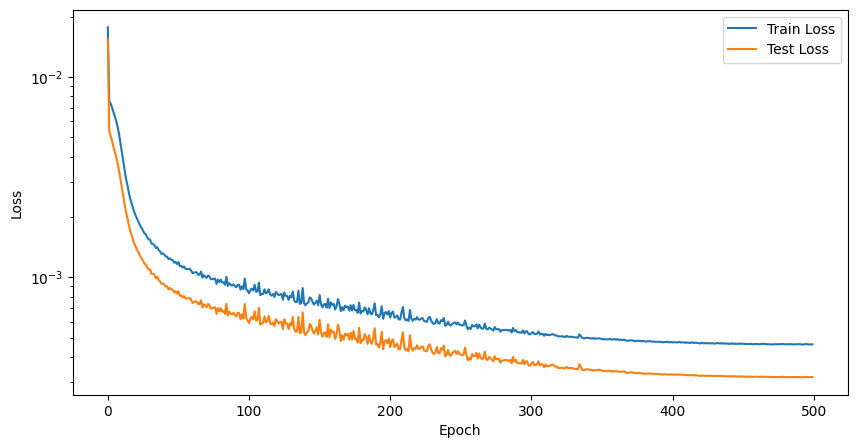

In [7]:
with open(model_rep_path / "logs/metrics.csv", "r") as f:
    lines = f.readlines()
    train_loss = [float(line.split(",")[1]) for line in lines[1:]]
    test_loss = [float(line.split(",")[2]) for line in lines[1:]]
    epochs = np.arange(len(train_loss))
    train_relative_loss = [float(line.split(",")[7]) for line in lines[1:]]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(epochs, train_loss, label="Train Loss")
ax.plot(epochs, test_loss, label="Test Loss")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend();

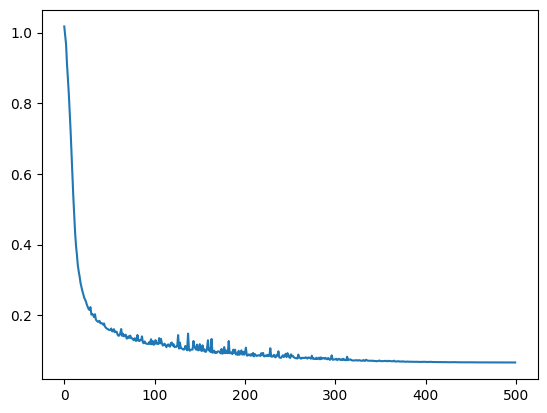

In [11]:
plt.plot(train_relative_loss)

# Model simulation

## In distribution

In [132]:
starting_point = torch.from_numpy(velocity_train[0]).unsqueeze(0).to(torch.float32).to(device)
predict_horizon = 6000 - 1

In [133]:
with torch.no_grad():
    simulation_train = model.predict_sequence(starting_point, pred_horizon=predict_horizon).cpu().numpy()

In [134]:
simulation_train = simulation_train.squeeze(0)

In [135]:
simulation_train.shape

(6000, 128, 128, 2)

### Results

In [136]:
def vorticity(velocity_field):
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]
    
    du_dy = np.gradient(u, axis=-1)
    dv_dx = np.gradient(v, axis=-2)
    
    return dv_dx - du_dy

#### Vorticity field visualisation

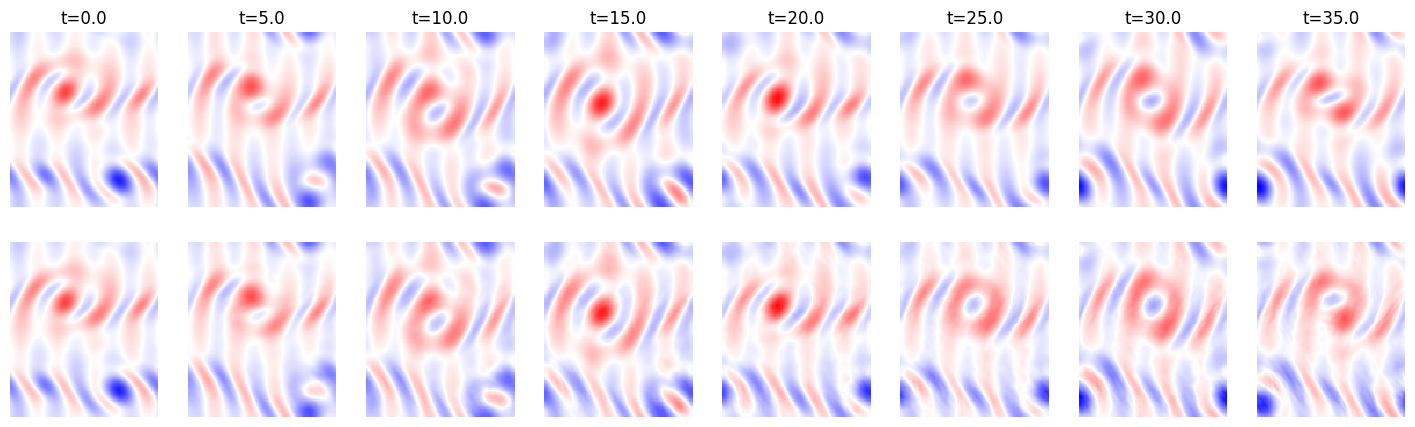

In [137]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_train).min(), vorticity(velocity_train).max()

for j in range(8):
    d = 50*j
    ax[0,j].pcolormesh(vorticity(velocity_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");


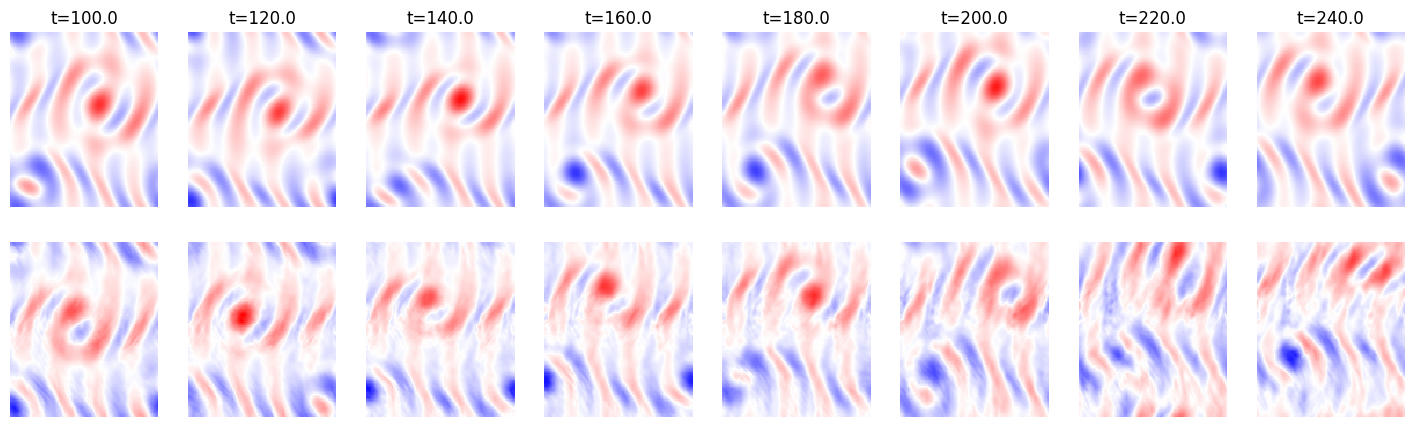

In [138]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_train).min(), vorticity(velocity_train).max()

for j in range(8):
    d = 1000 + 200*j
    ax[0,j].pcolormesh(vorticity(velocity_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

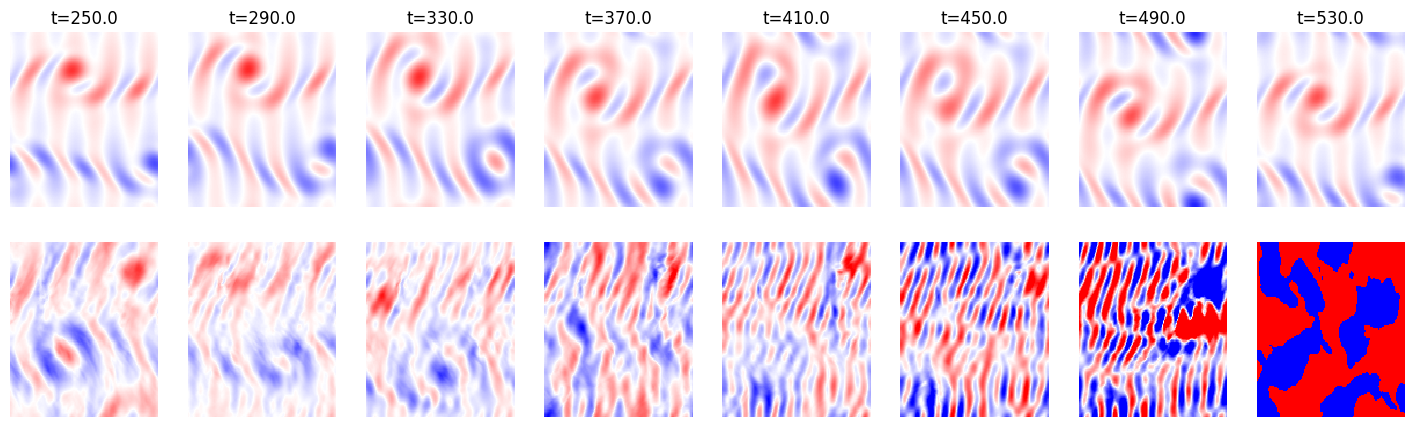

In [139]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_train).min(), vorticity(velocity_train).max()

for j in range(8):
    d = 2500 + 400*j
    ax[0,j].pcolormesh(vorticity(velocity_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

#### Kinetic ernergy

/var/folders/53/d3ng48y138s7ldywsyn64jj00000gn/T/ipykernel_97113/2403922862.py:2: RuntimeWarning: overflow encountered in square
  kinetic_energy_sim = 0.5 * np.sum(simulation_train**2, axis=-1)


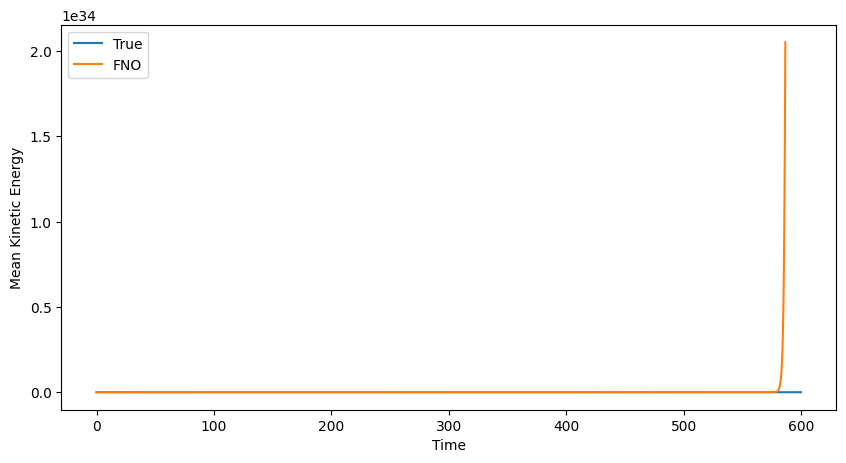

In [141]:
kinetic_energy = 0.5 * np.sum(velocity_train**2, axis=-1)
kinetic_energy_sim = 0.5 * np.sum(simulation_train**2, axis=-1)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

/var/folders/53/d3ng48y138s7ldywsyn64jj00000gn/T/ipykernel_97113/67377112.py:2: RuntimeWarning: overflow encountered in square
  kinetic_energy_sim = (0.5 * np.sum(simulation_train**2, axis=-1))[:4000]


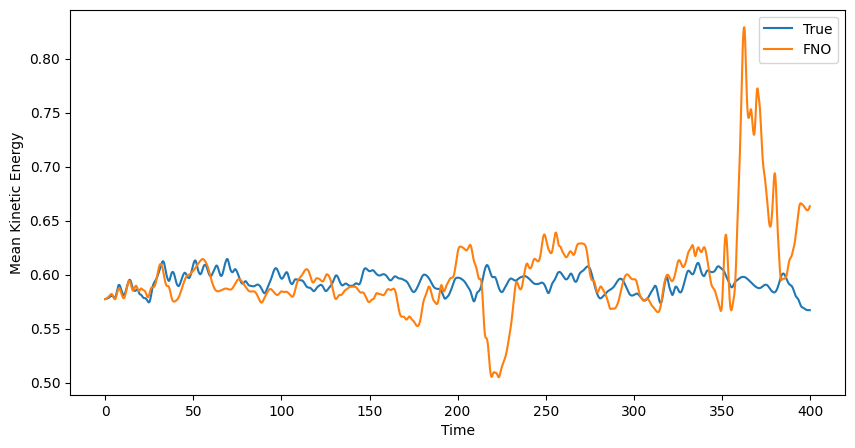

In [143]:
kinetic_energy = (0.5 * np.sum(velocity_train**2, axis=-1))[:4000]
kinetic_energy_sim = (0.5 * np.sum(simulation_train**2, axis=-1))[:4000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

/var/folders/53/d3ng48y138s7ldywsyn64jj00000gn/T/ipykernel_97113/1516598320.py:2: RuntimeWarning: overflow encountered in square
  kinetic_energy_sim = (0.5 * np.sum(simulation_train**2, axis=-1))[:2000]


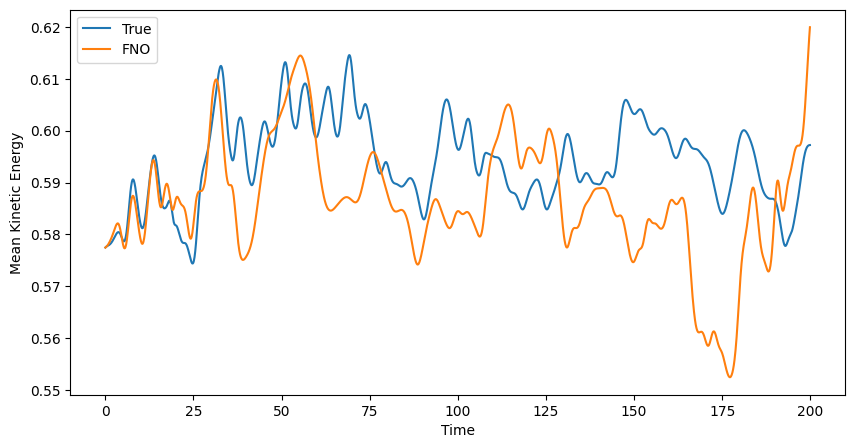

In [144]:
kinetic_energy = (0.5 * np.sum(velocity_train**2, axis=-1))[:2000]
kinetic_energy_sim = (0.5 * np.sum(simulation_train**2, axis=-1))[:2000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

#### Energy spectrum

In [100]:
def compute_classical_energy_spectrum(u):
        """
        Spectre classique par FFT directe des composantes de vitesse
        u : ndarray (t, nx, ny, 2)
        Returns: k_vals_classical, E_k_classical
        """
        tsteps, nx, ny, _ = u.shape
        E_k_sum = 0.0

        for t in range(tsteps):
            ux = u[t, :, :, 0]
            uy = u[t, :, :, 1]

            uxf = np.fft.fft2(ux)
            uyf = np.fft.fft2(uy)

            E2D = 0.5 * (np.abs(uxf)**2 + np.abs(uyf)**2) / (nx * ny)
            E2D = np.fft.fftshift(E2D)

            # Build radial wavenumber grid
            kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
            ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
            KX, KY = np.meshgrid(kx, ky, indexing='ij')
            k_mag = np.sqrt(KX**2 + KY**2)

            k_max = int(np.max(k_mag))
            E_k = np.zeros(k_max)
            for i in range(k_max):
                mask = (k_mag >= i) & (k_mag < i + 1)
                E_k[i] += np.sum(E2D[mask])

            E_k_sum += E_k

        E_k_classical = E_k_sum / tsteps
        k_vals_classical = np.arange(len(E_k_classical))
        return k_vals_classical, E_k_classical


In [145]:
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(velocity_train)
k_bin_centers, spectrum_binned_pred = compute_classical_energy_spectrum(simulation_train[0:30])


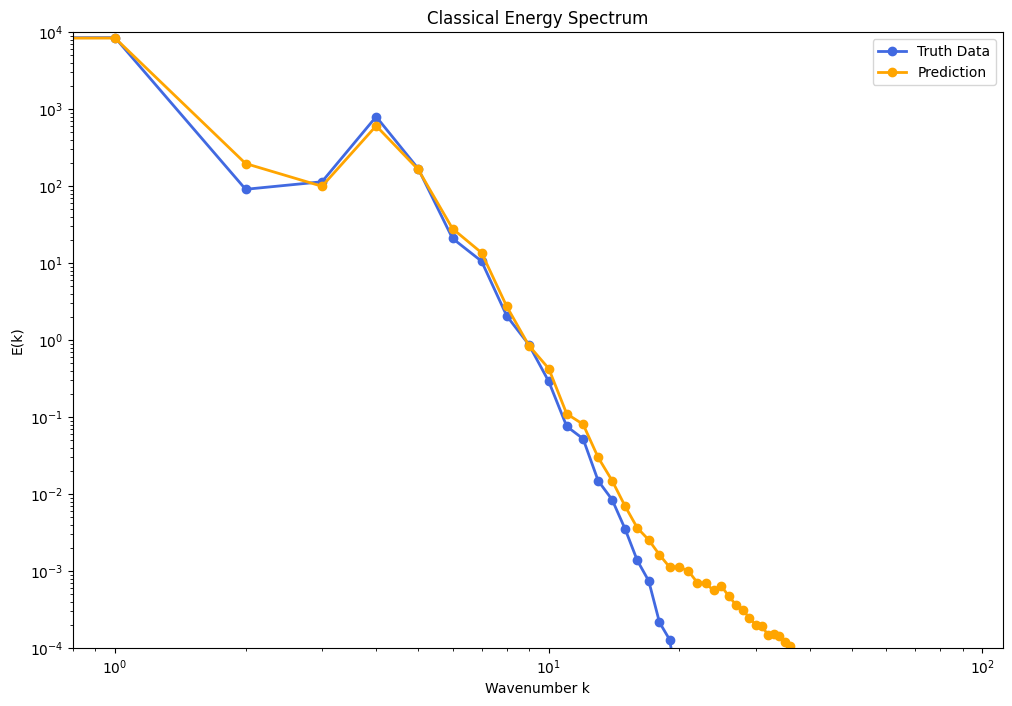

In [146]:
plt.figure(figsize=(12, 8))

plt.loglog(k_bin_centers, spectrum_binned_data, marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=6, label='Truth Data')
plt.loglog(k_bin_centers, spectrum_binned_pred, marker='o', linestyle='-', color='orange', linewidth=2, markersize=6, label='Prediction')
plt.legend()
plt.title("Classical Energy Spectrum")
plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.ylim(1e-4, 1e4);

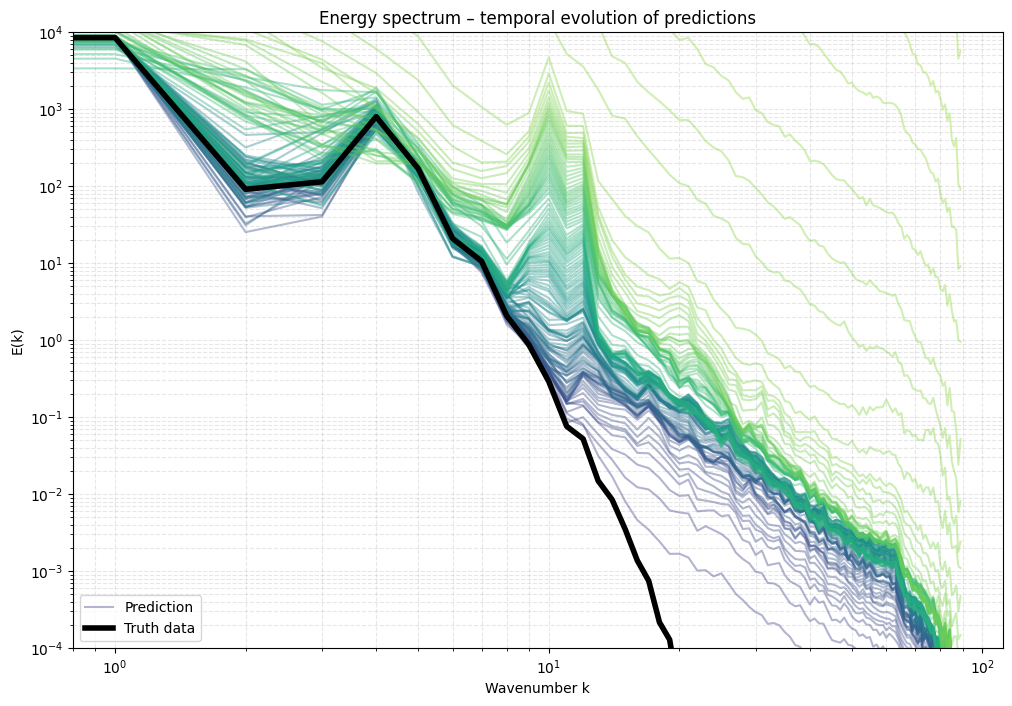

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

block_size = 40
nt = simulation_train.shape[0]
n_blocks = nt // block_size

# colormap pour le dégradé temporel
cmap = cm.viridis
colors = cmap(np.linspace(0.2, 0.95, n_blocks))

plt.figure(figsize=(12, 8))

# --- vérité (une seule fois) ---
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(velocity_train)



# --- prédictions par blocs ---
for i in range(n_blocks):
    start = i * block_size
    end = (i + 1) * block_size

    _, spectrum_binned_pred = compute_classical_energy_spectrum(
        simulation_train[start:end]
    )

    plt.loglog(
        k_bin_centers,
        spectrum_binned_pred,
        color=colors[i],
        alpha=0.4,
        linewidth=1.5,
        label="Prediction" if i == 0 else None
    )
plt.loglog(
    k_bin_centers,
    spectrum_binned_data,
    color="black",
    linewidth=4,
    label="Truth data"
)

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy spectrum – temporal evolution of predictions")
plt.ylim(1e-4, 1e4)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()


In [166]:
import matplotlib.pyplot as plt

def plot_velocity_distribution_comparison(velocity_true, velocity_pred, title_suffix=""):
    # flatten
    u_true = velocity_true[..., 0].flatten()
    v_true = velocity_true[..., 1].flatten()
    u_pred = velocity_pred[..., 0].flatten()
    v_pred = velocity_pred[..., 1].flatten()

    # --- U component ---
    plt.figure(figsize=(8, 6))
    plt.hist(u_true, bins=60, density=True, alpha=0.5,
             label="u – Truth", color="royalblue")
    plt.hist(u_pred, bins=60, density=True, alpha=0.5,
             label="u – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (u) {title_suffix}")
    plt.xlim(-3, 3)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- V component ---
    plt.figure(figsize=(8, 6))
    plt.hist(v_true, bins=60, density=True, alpha=0.5,
             label="v – Truth", color="royalblue")
    plt.hist(v_pred, bins=60, density=True, alpha=0.5,
             label="v – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.xlim(-3, 3)
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (v) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


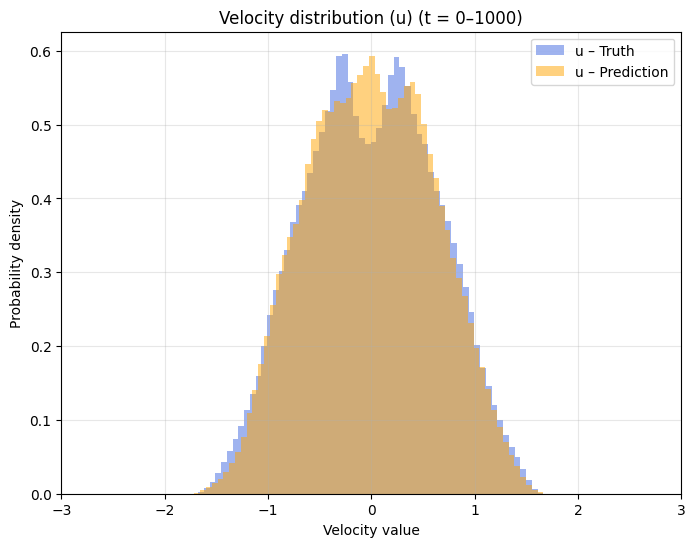

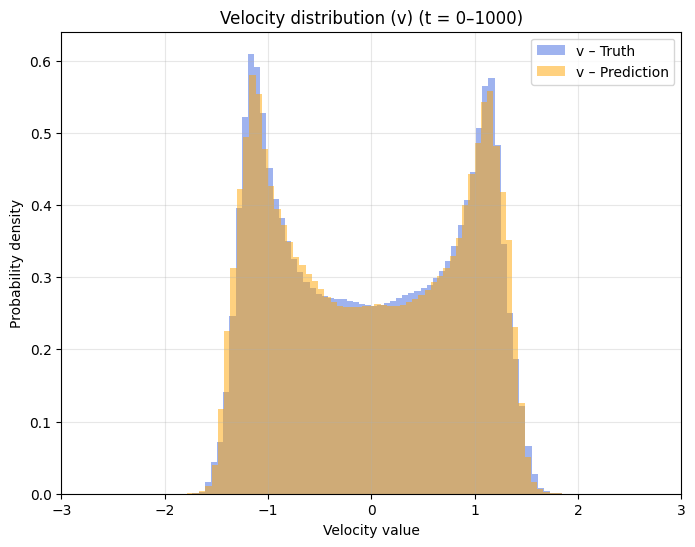

In [167]:
plot_velocity_distribution_comparison(
    velocity_train[:1000],
    simulation_train[:1000],
    title_suffix="(t = 0–1000)"
)


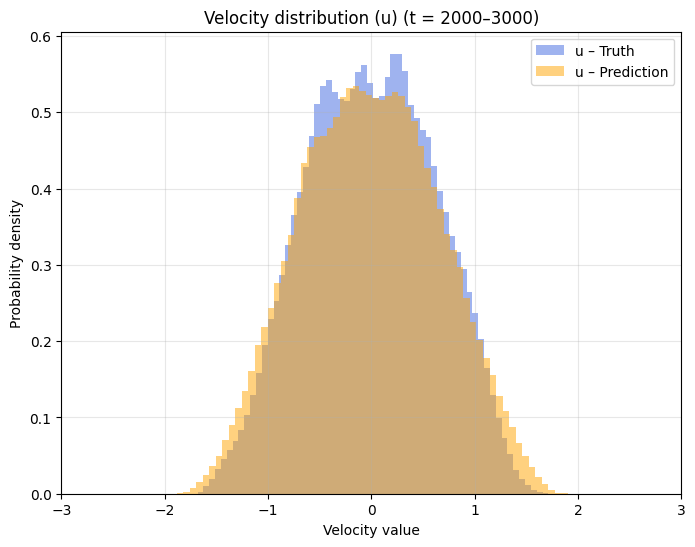

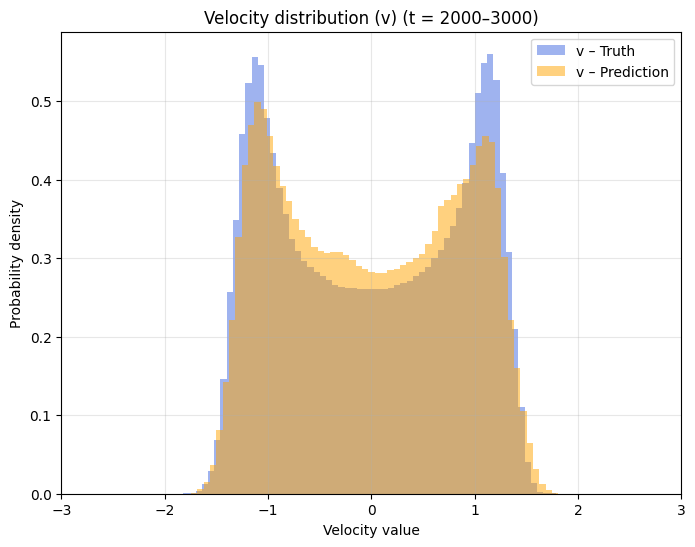

In [168]:
plot_velocity_distribution_comparison(
    velocity_train[2000:3000],
    simulation_train[2000:3000],
    title_suffix="(t = 2000–3000)"
)


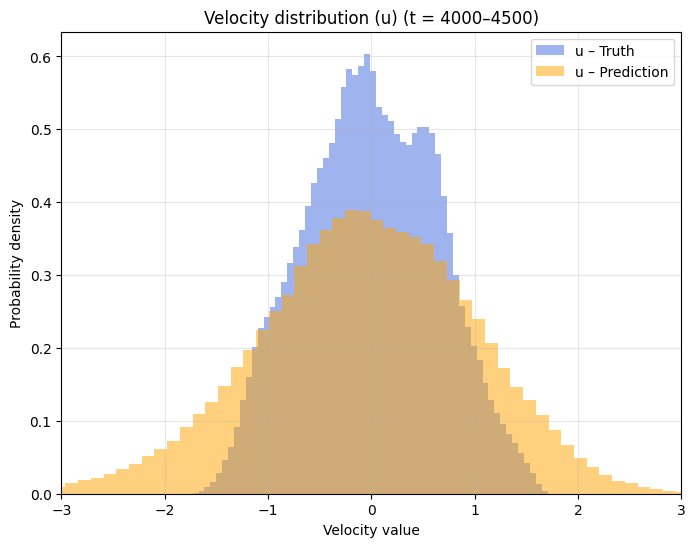

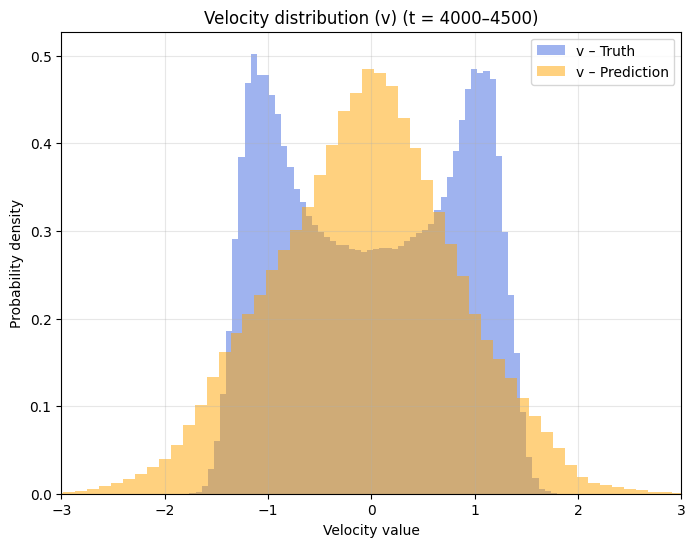

In [172]:
plot_velocity_distribution_comparison(
    velocity_train[4000:4500],
    simulation_train[4000:4500],
    title_suffix="(t = 4000–4500)"
)


In [193]:
import numpy as np

def temporal_autocorrelation(field, max_lag):
    """
    field: array (nt, nx, ny)
    max_lag: lag temporel max
    """
    nt = field.shape[0]
    field = field - field.mean()  # enlever la moyenne globale

    var = np.mean(field**2)
    corr = np.zeros(max_lag)

    for tau in range(max_lag):
        corr[tau] = np.mean(
            field[:nt - tau] * field[tau:nt]
        ) / var

    return corr

import matplotlib.pyplot as plt

def plot_velocity_autocorrelation(
    velocity_true,
    velocity_pred,
    max_lag=200,
    title_suffix=""
):
    # extraire composantes
    u_true = velocity_true[..., 0]
    v_true = velocity_true[..., 1]
    u_pred = velocity_pred[..., 0]
    v_pred = velocity_pred[..., 1]

    # autocorrélations
    corr_u_true = temporal_autocorrelation(u_true, max_lag)
    corr_u_pred = temporal_autocorrelation(u_pred, max_lag)

    corr_v_true = temporal_autocorrelation(v_true, max_lag)
    corr_v_pred = temporal_autocorrelation(v_pred, max_lag)

    lags = np.arange(max_lag)

    # --- U ---
    plt.figure(figsize=(8, 6))
    plt.plot(lags, corr_u_true, label="u – Truth", color="royalblue", linewidth=2)
    plt.plot(lags, corr_u_pred, label="u – Prediction", color="orange", linewidth=2)
    plt.xlabel("Time lag")
    plt.ylabel("Autocorrelation")
    plt.title(f"Temporal autocorrelation (u) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- V ---
    plt.figure(figsize=(8, 6))
    plt.plot(lags, corr_v_true, label="v – Truth", color="royalblue", linewidth=2)
    plt.plot(lags, corr_v_pred, label="v – Prediction", color="orange", linewidth=2)
    plt.xlabel("Time lag")
    plt.ylabel("Autocorrelation")
    plt.title(f"Temporal autocorrelation (v) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


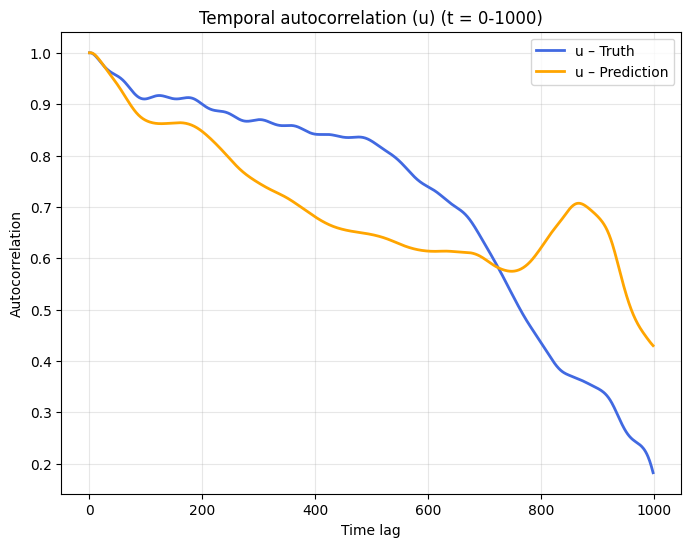

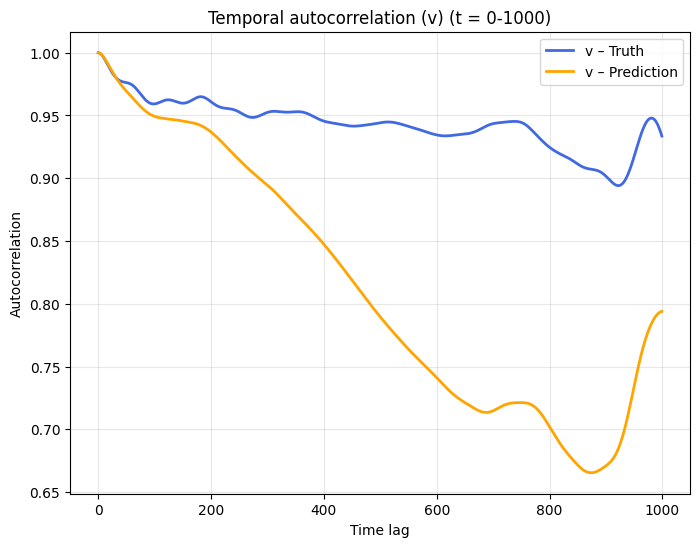

: 

In [ ]:
plot_velocity_autocorrelation(
    velocity_train[:1000],
    simulation_train[:1000],
    max_lag=1000,
    title_suffix="(t = 0-1000)"
)


## Out distribution

In [174]:
starting_point = torch.from_numpy(velocity_test[0]).unsqueeze(0).to(torch.float32).to(device)
predict_horizon = 6000 - 1

In [175]:
with torch.no_grad():
    simulation_test = model.predict_sequence(starting_point, pred_horizon=predict_horizon).cpu().numpy()

In [176]:
simulation_test = simulation_test.squeeze(0)

In [177]:
simulation_test.shape

(6000, 128, 128, 2)

### Results

In [178]:
def vorticity(velocity_field):
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]
    
    du_dy = np.gradient(u, axis=-1)
    dv_dx = np.gradient(v, axis=-2)
    
    return dv_dx - du_dy

#### Vorticity field visualisation

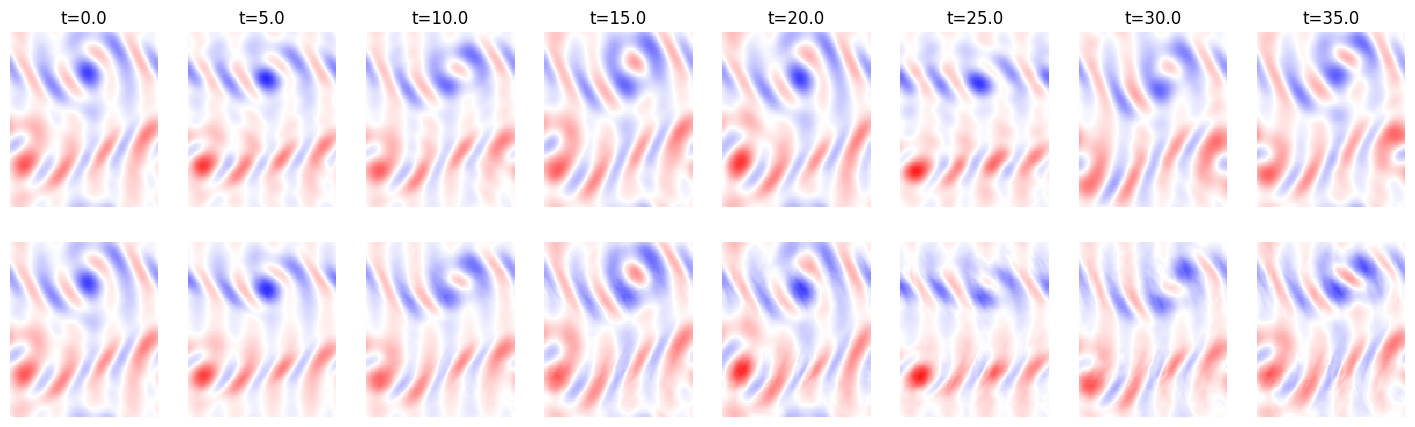

In [179]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_test).min(), vorticity(velocity_test).max()

for j in range(8):
    d = 50*j
    ax[0,j].pcolormesh(vorticity(velocity_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");


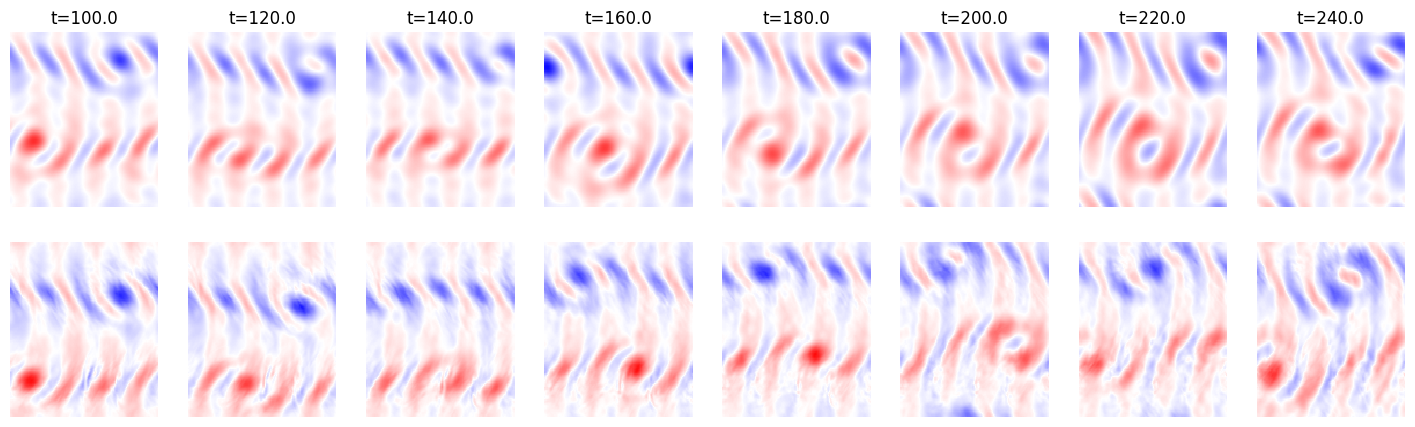

In [180]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_test).min(), vorticity(velocity_test).max()

for j in range(8):
    d = 1000 + 200*j
    ax[0,j].pcolormesh(vorticity(velocity_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

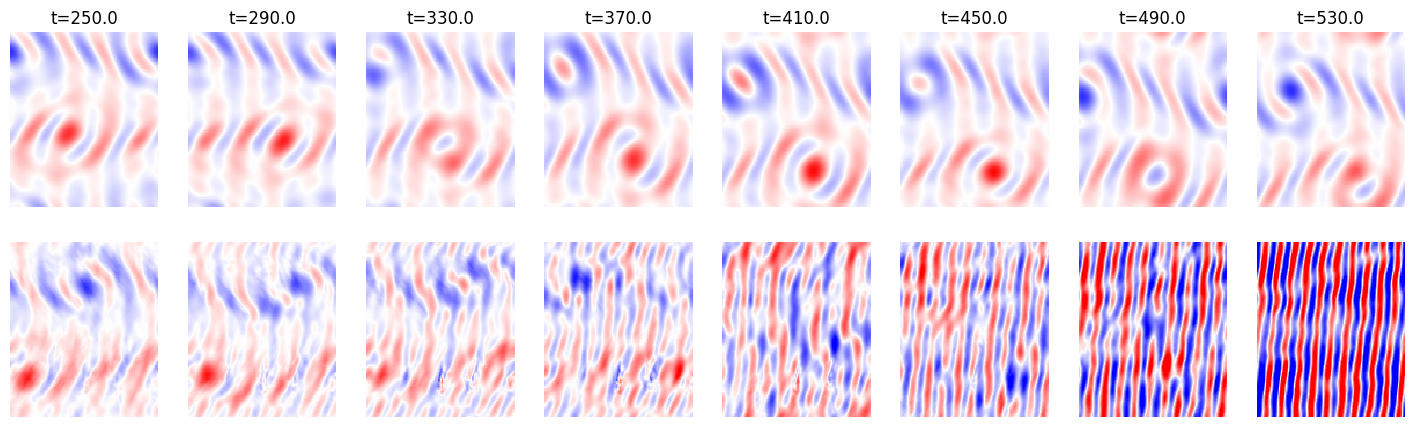

In [181]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_test).min(), vorticity(velocity_test).max()

for j in range(8):
    d = 2500 + 400*j
    ax[0,j].pcolormesh(vorticity(velocity_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_test[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

#### Kinetic ernergy

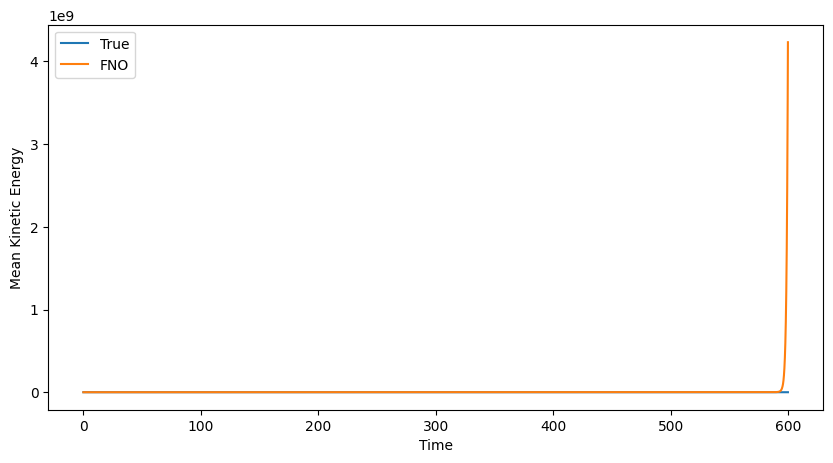

In [182]:
kinetic_energy = 0.5 * np.sum(velocity_test**2, axis=-1)
kinetic_energy_sim = 0.5 * np.sum(simulation_test**2, axis=-1)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

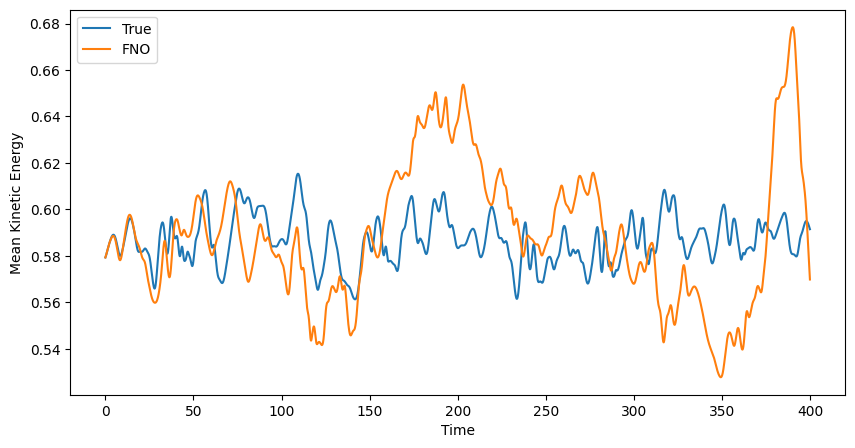

In [183]:
kinetic_energy = (0.5 * np.sum(velocity_test**2, axis=-1))[:4000]
kinetic_energy_sim = (0.5 * np.sum(simulation_test**2, axis=-1))[:4000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

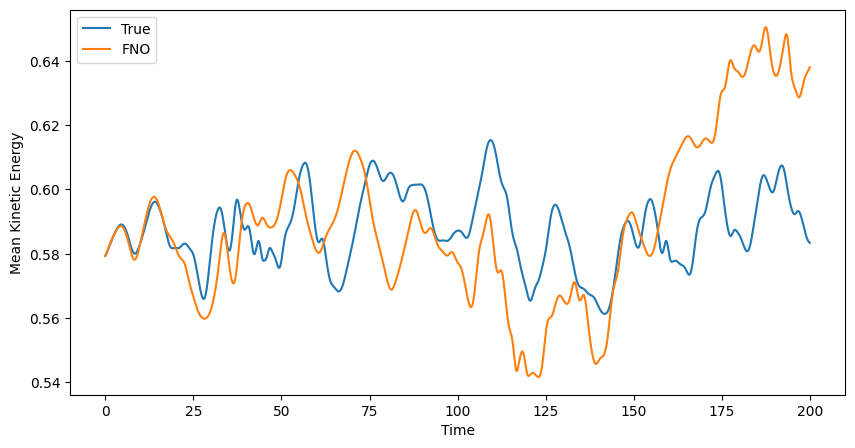

In [184]:
kinetic_energy = (0.5 * np.sum(velocity_test**2, axis=-1))[:2000]
kinetic_energy_sim = (0.5 * np.sum(simulation_test**2, axis=-1))[:2000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Kinetic Energy")
ax.legend();

#### Energy spectrum

In [185]:
def compute_classical_energy_spectrum(u):
        """
        Spectre classique par FFT directe des composantes de vitesse
        u : ndarray (t, nx, ny, 2)
        Returns: k_vals_classical, E_k_classical
        """
        tsteps, nx, ny, _ = u.shape
        E_k_sum = 0.0

        for t in range(tsteps):
            ux = u[t, :, :, 0]
            uy = u[t, :, :, 1]

            uxf = np.fft.fft2(ux)
            uyf = np.fft.fft2(uy)

            E2D = 0.5 * (np.abs(uxf)**2 + np.abs(uyf)**2) / (nx * ny)
            E2D = np.fft.fftshift(E2D)

            # Build radial wavenumber grid
            kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
            ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
            KX, KY = np.meshgrid(kx, ky, indexing='ij')
            k_mag = np.sqrt(KX**2 + KY**2)

            k_max = int(np.max(k_mag))
            E_k = np.zeros(k_max)
            for i in range(k_max):
                mask = (k_mag >= i) & (k_mag < i + 1)
                E_k[i] += np.sum(E2D[mask])

            E_k_sum += E_k

        E_k_classical = E_k_sum / tsteps
        k_vals_classical = np.arange(len(E_k_classical))
        return k_vals_classical, E_k_classical


In [186]:
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(velocity_test)
k_bin_centers, spectrum_binned_pred = compute_classical_energy_spectrum(simulation_test[0:30])


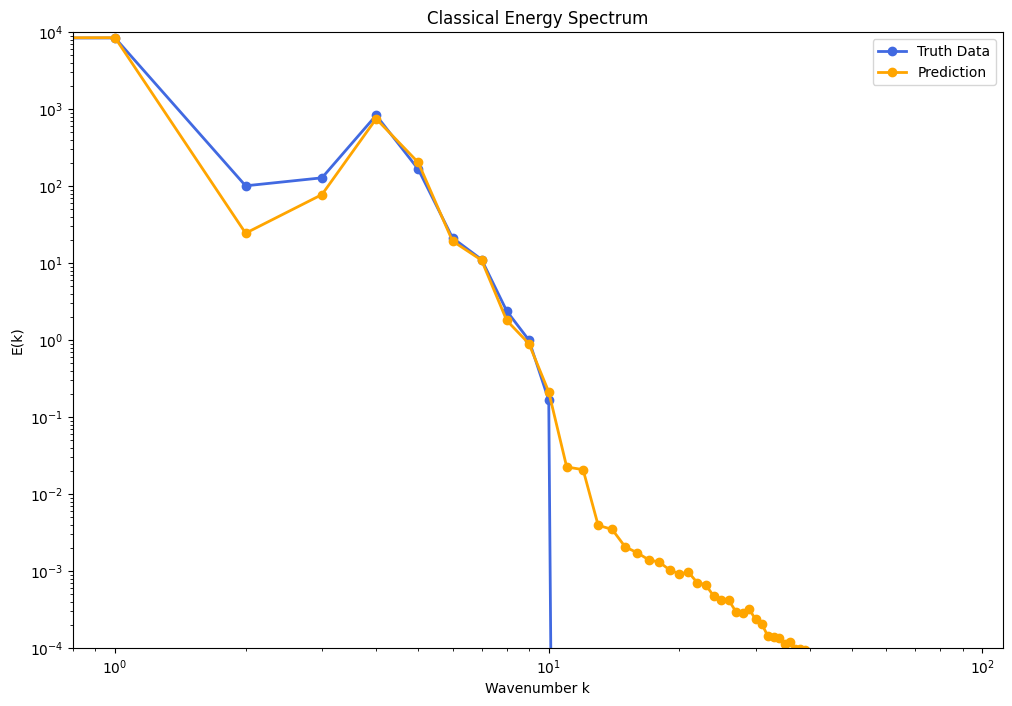

In [187]:
plt.figure(figsize=(12, 8))

plt.loglog(k_bin_centers, spectrum_binned_data, marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=6, label='Truth Data')
plt.loglog(k_bin_centers, spectrum_binned_pred, marker='o', linestyle='-', color='orange', linewidth=2, markersize=6, label='Prediction')
plt.legend()
plt.title("Classical Energy Spectrum")
plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.ylim(1e-4, 1e4);

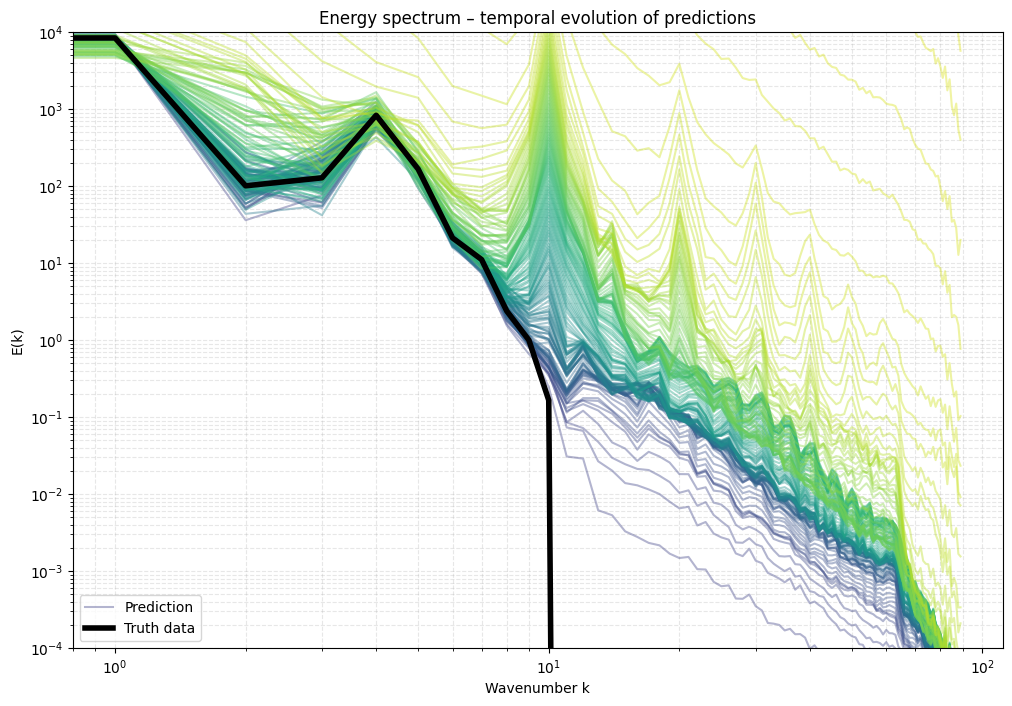

In [188]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

block_size = 40
nt = simulation_test.shape[0]
n_blocks = nt // block_size

# colormap pour le dégradé temporel
cmap = cm.viridis
colors = cmap(np.linspace(0.2, 0.95, n_blocks))

plt.figure(figsize=(12, 8))

# --- vérité (une seule fois) ---
k_bin_centers, spectrum_binned_data = compute_classical_energy_spectrum(velocity_test)



# --- prédictions par blocs ---
for i in range(n_blocks):
    start = i * block_size
    end = (i + 1) * block_size

    _, spectrum_binned_pred = compute_classical_energy_spectrum(
        simulation_test[start:end]
    )

    plt.loglog(
        k_bin_centers,
        spectrum_binned_pred,
        color=colors[i],
        alpha=0.4,
        linewidth=1.5,
        label="Prediction" if i == 0 else None
    )
plt.loglog(
    k_bin_centers,
    spectrum_binned_data,
    color="black",
    linewidth=4,
    label="Truth data"
)

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy spectrum – temporal evolution of predictions")
plt.ylim(1e-4, 1e4)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()


In [189]:
import matplotlib.pyplot as plt

def plot_velocity_distribution_comparison(velocity_true, velocity_pred, title_suffix=""):
    # flatten
    u_true = velocity_true[..., 0].flatten()
    v_true = velocity_true[..., 1].flatten()
    u_pred = velocity_pred[..., 0].flatten()
    v_pred = velocity_pred[..., 1].flatten()

    # --- U component ---
    plt.figure(figsize=(8, 6))
    plt.hist(u_true, bins=60, density=True, alpha=0.5,
             label="u – Truth", color="royalblue")
    plt.hist(u_pred, bins=60, density=True, alpha=0.5,
             label="u – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (u) {title_suffix}")
    plt.xlim(-3, 3)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- V component ---
    plt.figure(figsize=(8, 6))
    plt.hist(v_true, bins=60, density=True, alpha=0.5,
             label="v – Truth", color="royalblue")
    plt.hist(v_pred, bins=60, density=True, alpha=0.5,
             label="v – Prediction", color="orange")
    plt.xlabel("Velocity value")
    plt.xlim(-3, 3)
    plt.ylabel("Probability density")
    plt.title(f"Velocity distribution (v) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


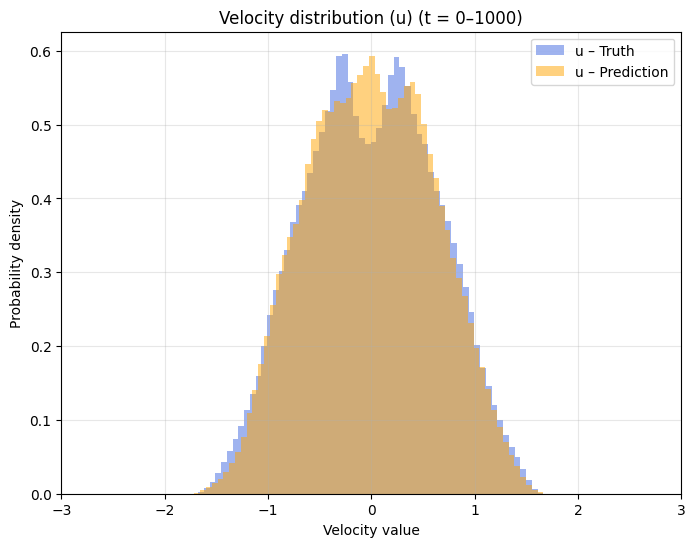

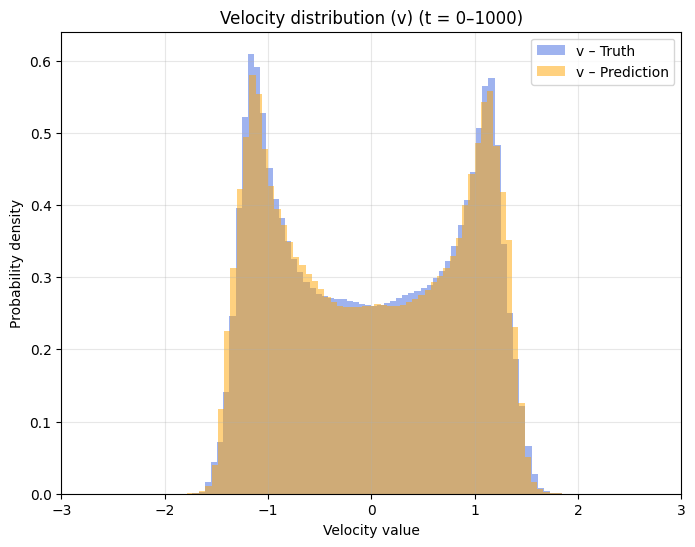

In [190]:
plot_velocity_distribution_comparison(
    velocity_train[:1000],
    simulation_train[:1000],
    title_suffix="(t = 0–1000)"
)


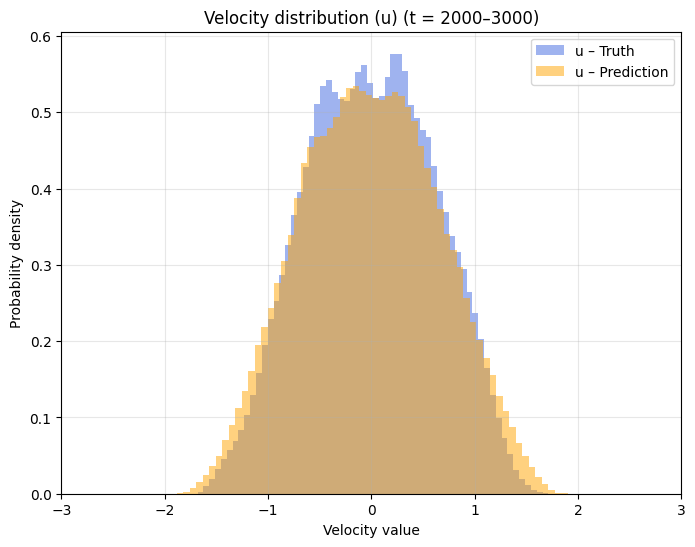

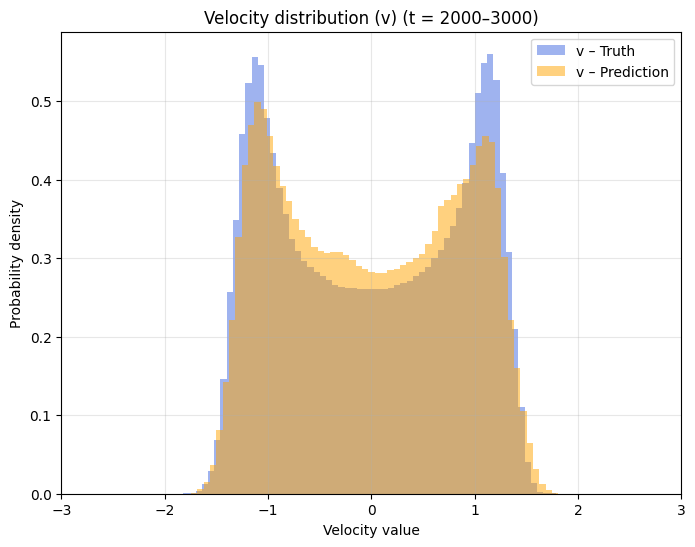

In [191]:
plot_velocity_distribution_comparison(
    velocity_train[2000:3000],
    simulation_train[2000:3000],
    title_suffix="(t = 2000–3000)"
)


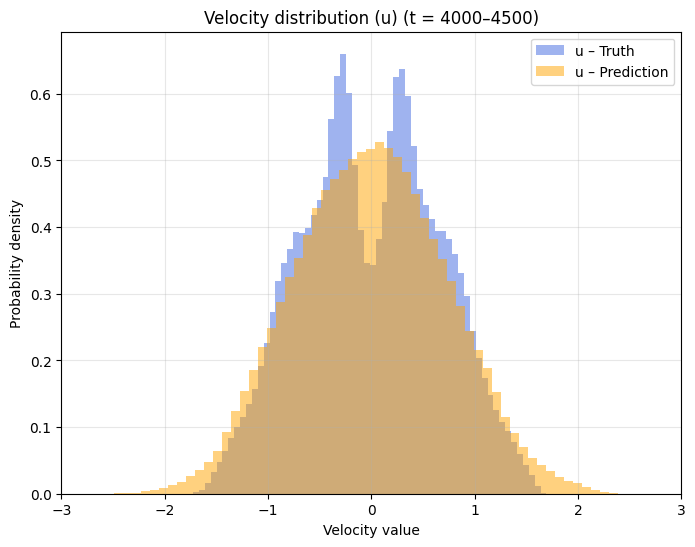

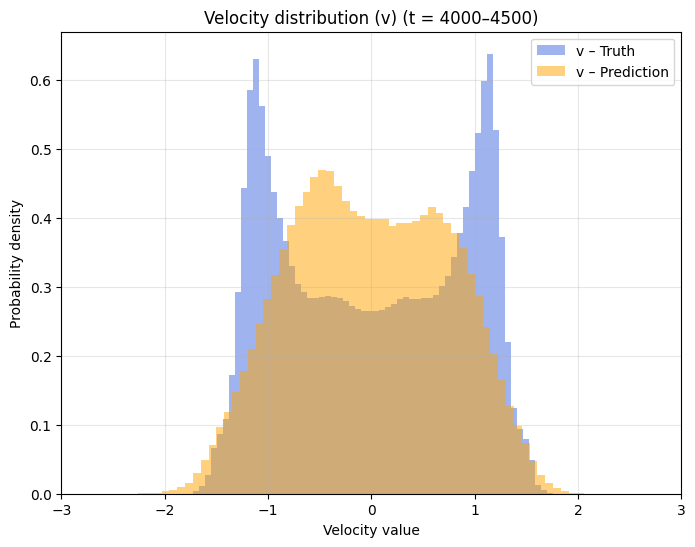

In [192]:
plot_velocity_distribution_comparison(
    velocity_test[4000:4500],
    simulation_test[4000:4500],
    title_suffix="(t = 4000–4500)"
)


## resolution 64

In [88]:
with h5py.File(train_path / "sim1.h5", "r") as f:
    velocity_train = f["velocity_field"][:,::2,::2,:]
dt = 0.1
                

In [89]:
starting_point = torch.from_numpy(velocity_train[0]).unsqueeze(0).to(torch.float32).to(device)
predict_horizon = 6000 - 1

In [90]:
with torch.no_grad():
    simulation_train = model.predict_sequence(starting_point, pred_horizon=predict_horizon).cpu().numpy()

In [91]:
simulation_train = simulation_train.squeeze(0)

In [92]:
simulation_train.shape

(6000, 64, 64, 2)

### Results

In [93]:
def vorticity(velocity_field):
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]
    
    du_dy = np.gradient(u, axis=-1)
    dv_dx = np.gradient(v, axis=-2)
    
    return dv_dx - du_dy

#### Vorticity field visualisation

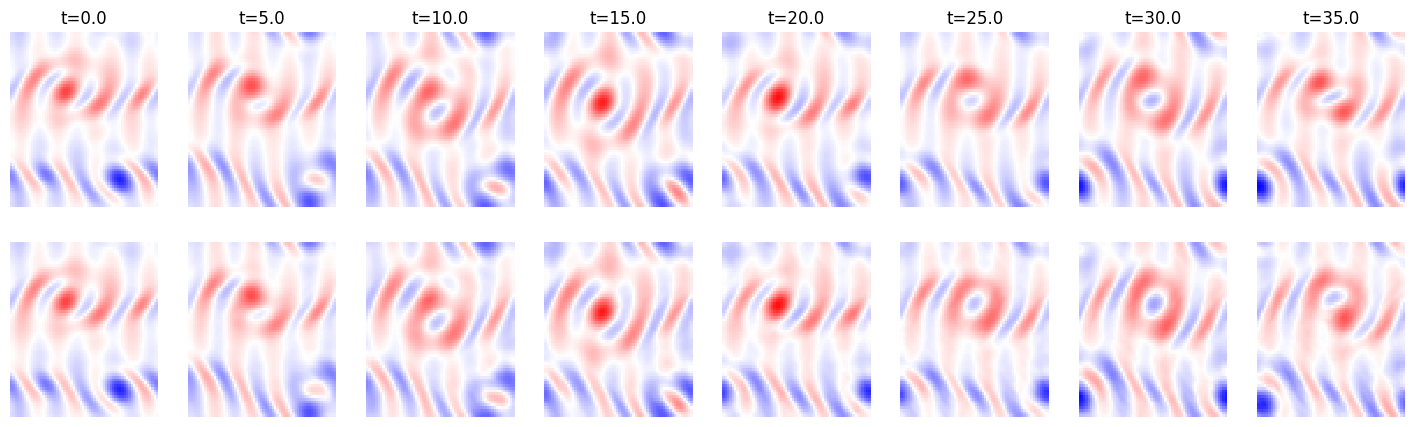

In [94]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_train).min(), vorticity(velocity_train).max()

for j in range(8):
    d = 50*j
    ax[0,j].pcolormesh(vorticity(velocity_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");


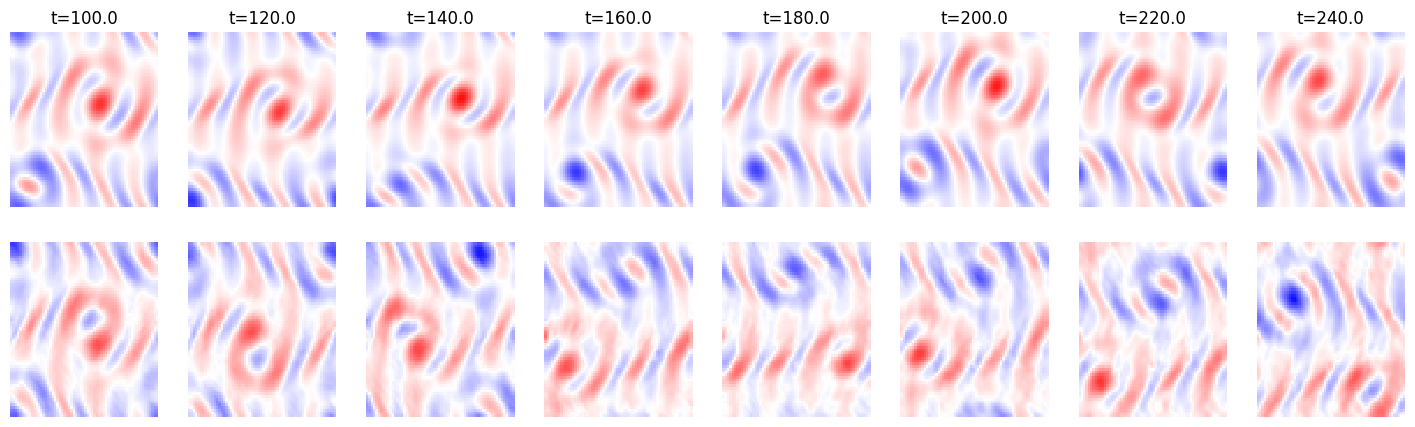

In [96]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_train).min(), vorticity(velocity_train).max()

for j in range(8):
    d = 1000 + 200*j
    ax[0,j].pcolormesh(vorticity(velocity_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

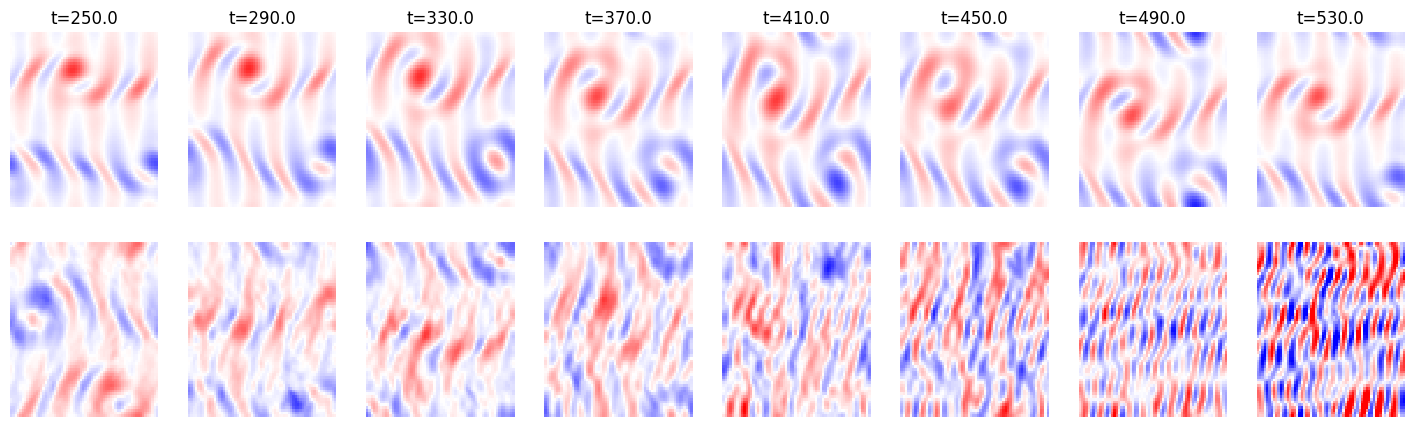

In [97]:
fig, ax = plt.subplots(2,8,figsize=(18,5))

vmin, vmax = vorticity(velocity_train).min(), vorticity(velocity_train).max()

for j in range(8):
    d = 2500 + 400*j
    ax[0,j].pcolormesh(vorticity(velocity_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[1,j].pcolormesh(vorticity(simulation_train[d]), vmin=vmin, vmax=vmax, cmap='bwr')
    ax[0,j].set_title(f"t={d*dt}")
    ax[0,j].axis('off')
    ax[1,j].axis('off')
ax[0,1].set_ylabel("Reconstructed");

#### Kinetic ernergy

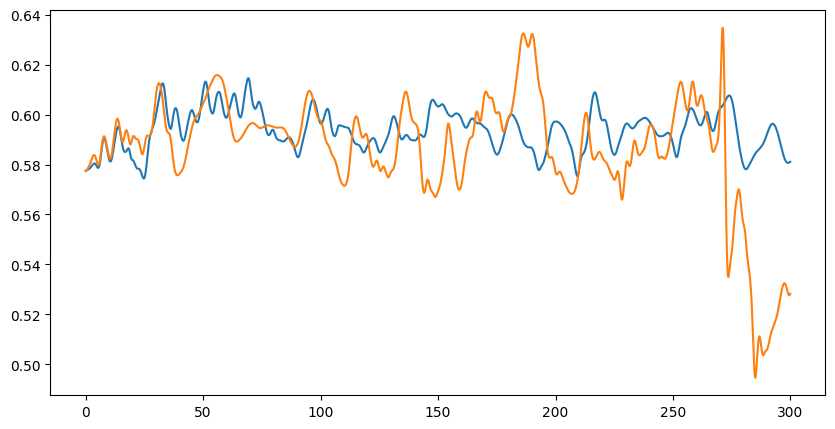

In [125]:
kinetic_energy = (0.5 * np.sum(velocity_train**2, axis=-1))[:3000]
kinetic_energy_sim = (0.5 * np.sum(simulation_train**2, axis=-1))[:3000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(kinetic_energy.shape[0]) * dt, kinetic_energy.mean(axis=(1,2)), label="True")
ax.plot(np.arange(kinetic_energy_sim.shape[0]) * dt, kinetic_energy_sim.mean(axis=(1,2)), label="FNO");

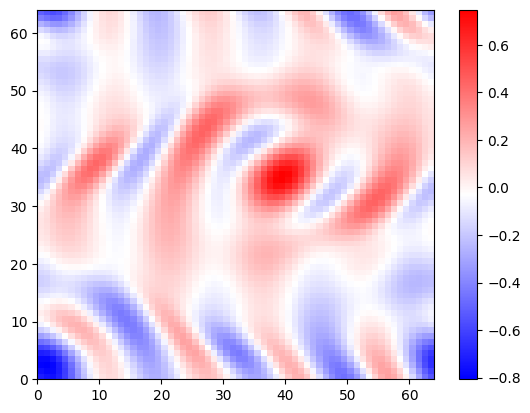

In [99]:
c = plt.pcolormesh(vorticity(velocity_train[1200]), cmap='bwr')
plt.colorbar(c)

## Out distribution